# Day 41: Predicting High-Risk Customers Before They Churn

In this notebook, we combine customer behavior, segmentation, and churn signals to build a predictive risk scoring model. We will rank customers by churn probability and visualize high-risk groups.

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Set plot style
sns.set_theme(style='whitegrid')

# Load the generated dataset
df = pd.read_csv('../data/churn_data.csv')
display(df.head())


,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,support_tickets,days_since_last_login,satisfaction_score,churn
0,CUST_00001,45,1,75.259582,63.314375,Two year,0,5,5,0
1,CUST_00002,38,56,95.366670,5411.121006,One year,0,16,1,0
2,CUST_00003,47,4,61.378331,206.028729,Month-to-month,1,3,4,0
3,CUST_00004,58,30,75.145602,2516.333192,Month-to-month,0,20,5,0
4,CUST_00005,37,12,65.409356,805.822875,One year,0,22,2,0


## 2. Exploratory Data Analysis (EDA)

,age,tenure_months,monthly_charges,total_charges,support_tickets,days_since_last_login,satisfaction_score,churn
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000
mean,39.750000,36.166400,65.189511,2373.220527,0.48600,9.500800,3.017600,0.064600
std,11.557033,20.432274,24.051321,1712.301317,0.68724,9.960072,1.412972,0.245843
min,18.000000,1.000000,15.000000,25.057856,0.00000,0.000000,1.000000,0.000000
25%,32.000000,18.000000,48.581458,1004.554460,0.00000,2.000000,2.000000,0.000000
50%,40.000000,36.000000,65.076549,2037.034472,0.00000,6.000000,3.000000,0.000000
75%,47.000000,54.000000,81.231403,3439.266914,1.00000,13.000000,4.000000,0.000000
max,80.000000,71.000000,150.000000,9615.282925,5.00000,84.000000,5.000000,1.000000


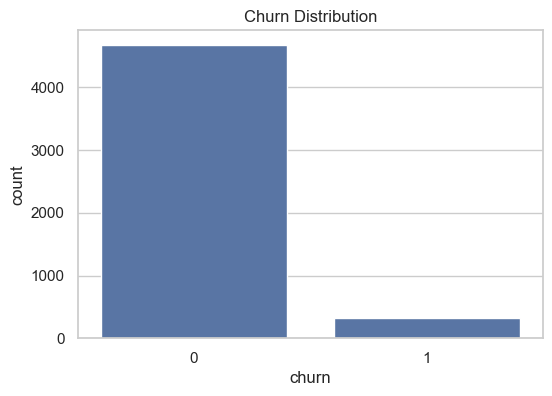

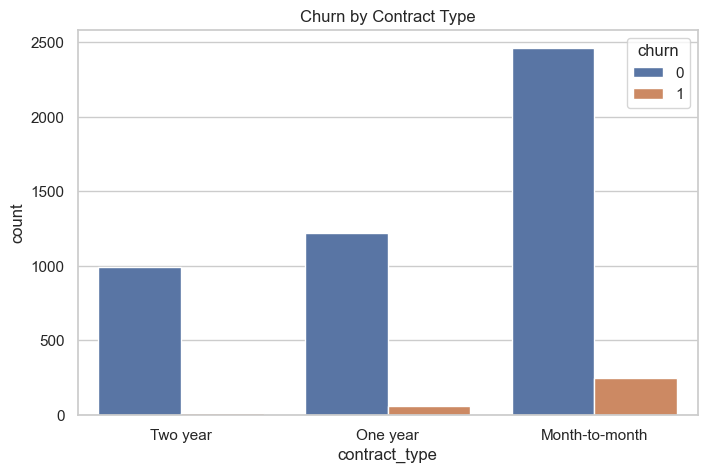

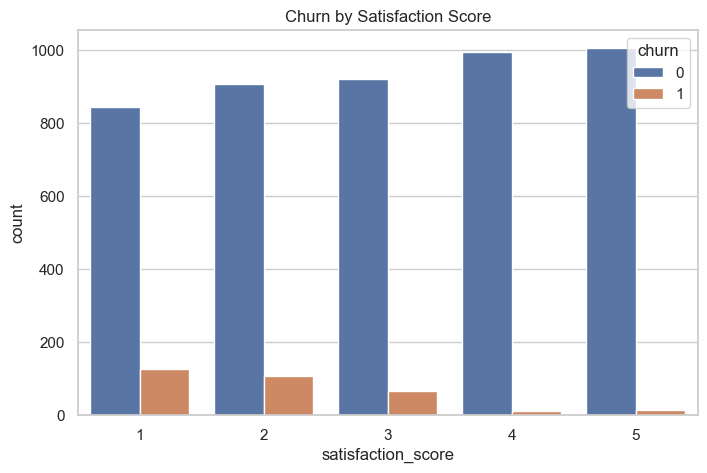

In [2]:
# Check basic stats
display(df.describe())

# Check churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df)
plt.title('Churn Distribution')
plt.show()

# Churn vs Contract Type
plt.figure(figsize=(8, 5))
sns.countplot(x='contract_type', hue='churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

# Satisfaction Score vs Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='satisfaction_score', hue='churn', data=df)
plt.title('Churn by Satisfaction Score')
plt.show()


## 3. Data Preprocessing & Feature Engineering

In [3]:
# Encode categorical features
le = LabelEncoder()
df['contract_type_encoded'] = le.fit_transform(df['contract_type'])

# Select features and target
features = [
    'age', 'tenure_months', 'monthly_charges', 'total_charges', 
    'contract_type_encoded', 'support_tickets', 
    'days_since_last_login', 'satisfaction_score'
]
X = df[features]
y = df['churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Model Training (Random Forest)

In [4]:
# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       935
           1       1.00      0.03      0.06        65

    accuracy                           0.94      1000
   macro avg       0.97      0.52      0.51      1000
weighted avg       0.94      0.94      0.91      1000

ROC-AUC Score: 0.7997


## 5. Feature Importance

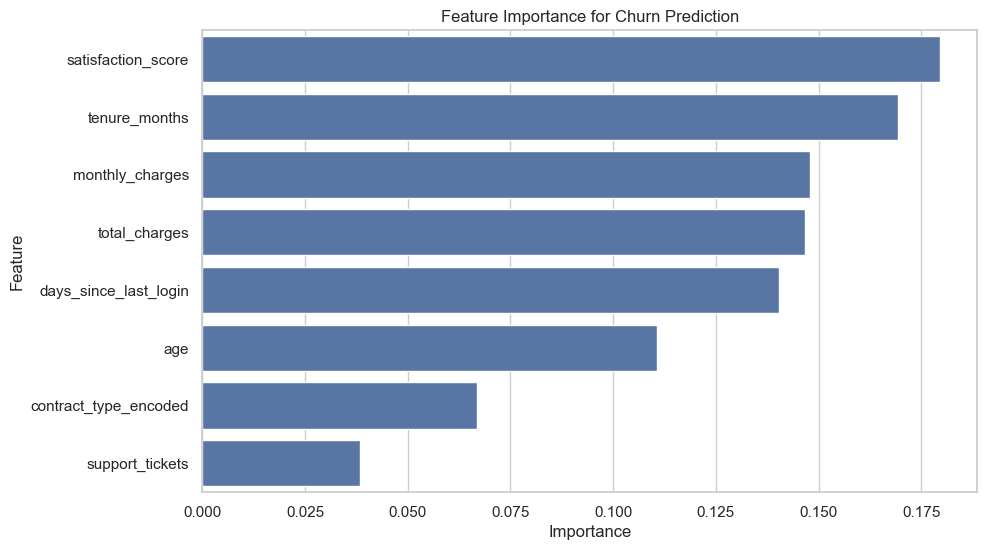

In [5]:
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importance for Churn Prediction')
plt.show()


## 6. Risk Scoring & Ranking

In [7]:
# Apply model to entire dataset to generate risk scores
X_scaled_all = scaler.transform(X)
df['churn_risk_score'] = rf_model.predict_proba(X_scaled_all)[:, 1]

# Segment into risk groups
df['risk_group'] = pd.cut(df['churn_risk_score'], bins=[-0.01, 0.25, 0.5, 0.75, 1.01], labels=['Low', 'Medium', 'High', 'Critical'])

# View top 10 most critical customers
high_risk_customers = df.sort_values(by='churn_risk_score', ascending=False)
display(high_risk_customers[['customer_id', 'contract_type', 'satisfaction_score', 'churn_risk_score', 'risk_group']].head(10))

# Save the augmented dataset
df.to_csv('../data/churn_scored.csv', index=False)
print("Saved scored customers to ../data/churn_scored.csv")


,customer_id,contract_type,satisfaction_score,churn_risk_score,risk_group
1739,CUST_01740,Month-to-month,1,0.88,Critical
2233,CUST_02234,Month-to-month,1,0.85,Critical
3121,CUST_03122,Month-to-month,1,0.84,Critical
2483,CUST_02484,Month-to-month,4,0.84,Critical
4916,CUST_04917,Month-to-month,2,0.83,Critical
698,CUST_00699,Month-to-month,1,0.82,Critical
2574,CUST_02575,Month-to-month,1,0.80,Critical
1230,CUST_01231,Month-to-month,3,0.80,Critical
536,CUST_00537,Month-to-month,1,0.80,Critical
423,CUST_00424,Month-to-month,1,0.79,Critical


Saved scored customers to ../data/churn_scored.csv
